In [1]:
import numpy as np
import pandas as pd

In [2]:
!pip install numpy
!pip install scikit-learn-extra
!pip install --upgrade scikit-learn
!pip install faiss-cpu

In [3]:
#Load the dataset as "retail" 
retail = pd.read_csv(r"C:\Users\wongj\Downloads\OnlineRetail.csv", encoding='utf-8-sig')

In [4]:
#Display first few rows of data to get an overview of sample data
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceMonth,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12,3.39,17850.0,United Kingdom


In [5]:
#Understand the data type of each feature
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     541909 non-null  object 
 1   StockCode     541909 non-null  object 
 2   Description   540455 non-null  object 
 3   Quantity      541909 non-null  int64  
 4   InvoiceMonth  541909 non-null  int64  
 5   UnitPrice     541909 non-null  float64
 6   CustomerID    406829 non-null  float64
 7   Country       541909 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 33.1+ MB


In [6]:
#Basic statistics
retail.describe()

,Quantity,InvoiceMonth,UnitPrice,CustomerID
count,541909.000000,541909.000000,541909.000000,406829.000000
mean,9.552250,7.553128,4.611114,15287.690570
std,218.081158,3.509055,96.759853,1713.600303
min,-80995.000000,1.000000,-11062.060000,12346.000000
25%,1.000000,5.000000,1.250000,13953.000000
50%,3.000000,8.000000,2.080000,15152.000000
75%,10.000000,11.000000,4.130000,16791.000000
max,80995.000000,12.000000,38970.000000,18287.000000


In [7]:
#Python Visualization Tool
import matplotlib.pyplot as plt
import seaborn as sns

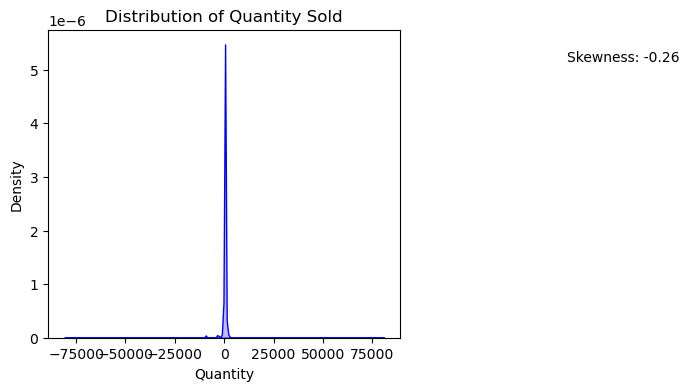

In [8]:
# ---- Exploratory Data Analysis ----
# Distribution of 'Quantity'
plt.figure(figsize=(10, 4))
quantity_skewness = retail.Quantity.skew()

plt.subplot(1, 2, 1)
sns.kdeplot(x = 'Quantity', data=retail, fill=True, color='blue')
plt.xlabel('Quantity')
plt.ylabel('Density')
plt.title('Distribution of Quantity Sold')

#Display the skewness value
plt.figtext(0.7, 0.8, f'Skewness: {quantity_skewness:.2f}',fontsize=10, ha='center')
plt.show()

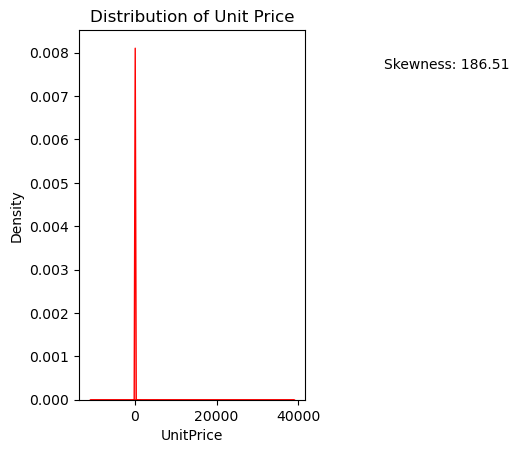

In [9]:
unit_price_skewness = retail.UnitPrice.skew()

# Distribution of UnitPrice
plt.subplot(1, 2, 1)
sns.kdeplot(x = 'UnitPrice', data=retail, fill=True, color='red')
plt.xlabel('UnitPrice')
plt.ylabel('Density')
plt.title('Distribution of Unit Price')

#Display the skewness value
plt.figtext(0.7, 0.8, f'Skewness: {unit_price_skewness:.2f}',fontsize=10, ha='center')
plt.show()

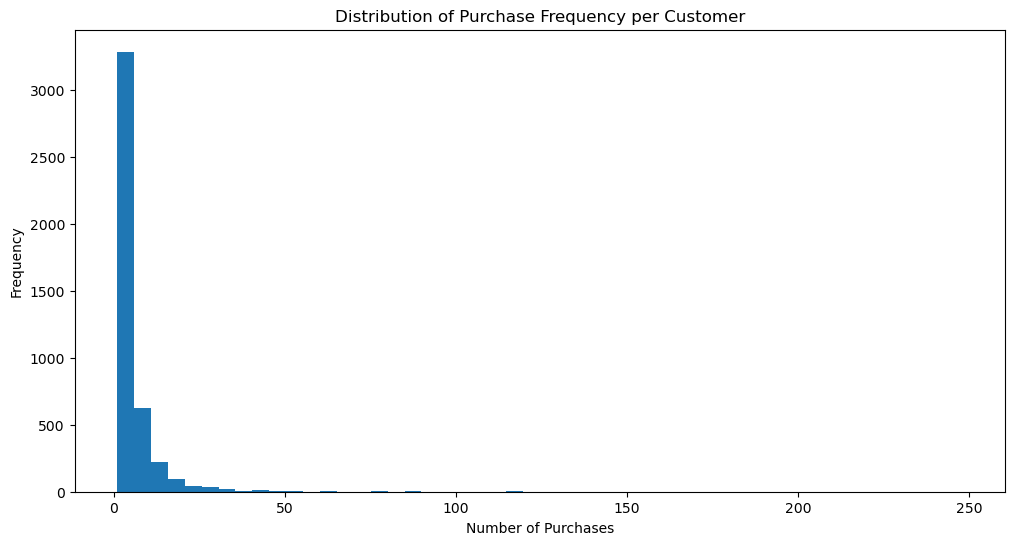

In [10]:
#Count of customerID appeared in which the "InvoiceNo" is distinct
purchase_frequency = retail.groupby('CustomerID')['InvoiceNo'].nunique()
purchase_frequency.plot(kind='hist', bins=50, figsize=(12, 6))
plt.title('Distribution of Purchase Frequency per Customer')
plt.xlabel('Number of Purchases')
plt.show()

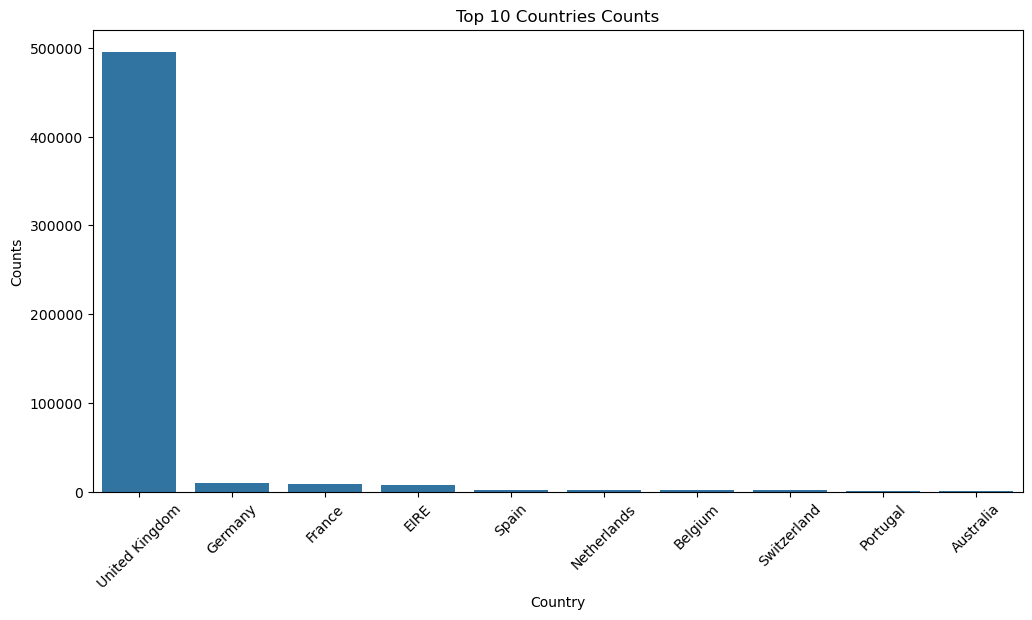

Lowest Count:'Saudi Arabia', 10 transactions


In [11]:
#Count of country appeared
country_counts = retail['Country'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index[:10], y=country_counts.values[:10])
plt.title('Top 10 Countries Counts')
plt.xlabel('Country')
plt.ylabel('Counts')
plt.xticks(rotation=45)
plt.show()

# Determine the country with the lowest count
lowest_country = country_counts.idxmin()
lowest_count = country_counts.min()
print(f"Lowest Count:'{lowest_country}', {lowest_count} transactions")

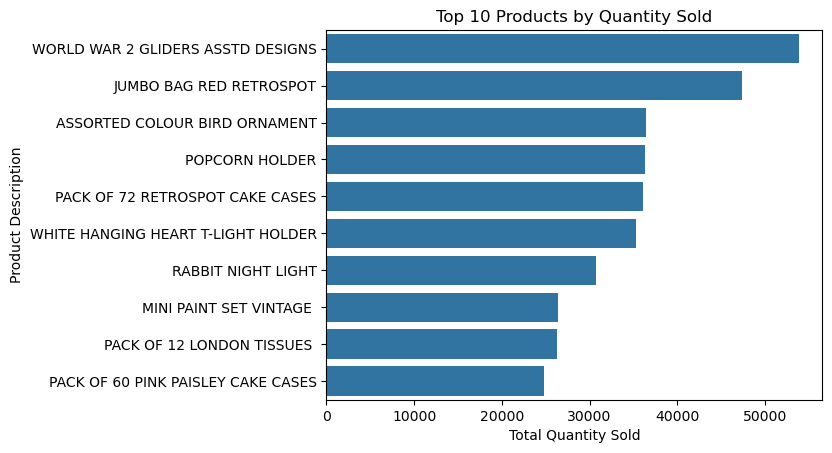

Product with Lowest Quantity Sold: 'printing smudges/thrown away', Quantity Sold: -19200


In [12]:
#Count of product from quantity
top_products = retail.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index)
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.title('Top 10 Products by Quantity Sold')
plt.show()

# Determine the product with the lowest quantity sold
lowest_product = retail.groupby('Description')['Quantity'].sum().idxmin()
lowest_product_count = retail.groupby('Description')['Quantity'].sum().min()

print(f"Product with Lowest Quantity Sold: '{lowest_product}', Quantity Sold: {lowest_product_count}")

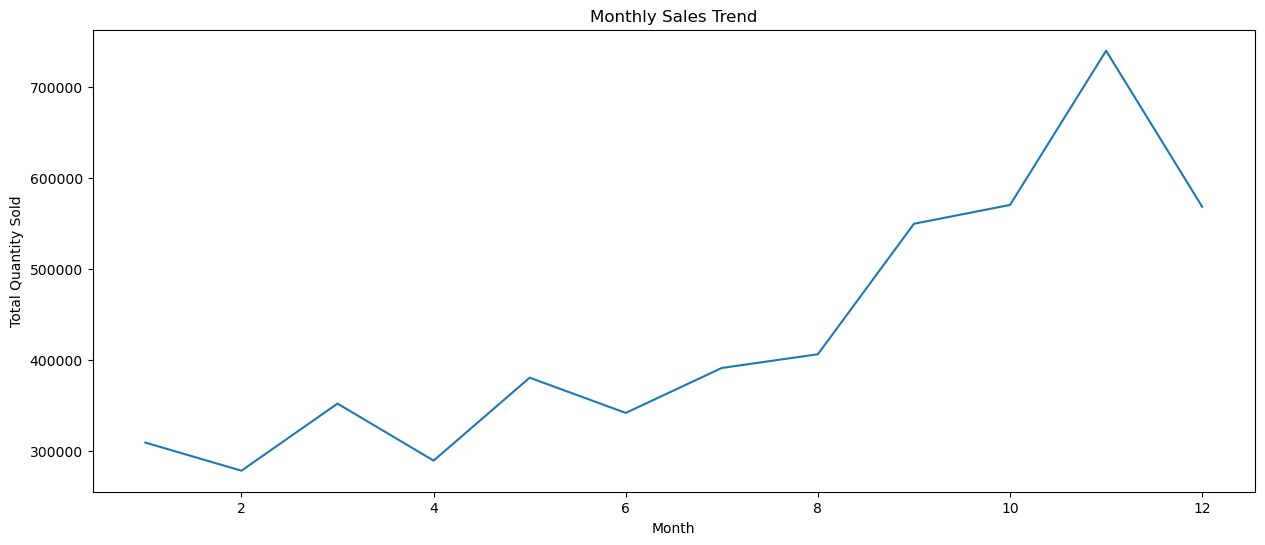

In [13]:
# Group by month, then sum the quantities
monthly_sales = retail.groupby(retail['InvoiceMonth'])['Quantity'].sum()

# Plot the monthly sales trend
monthly_sales.plot(kind='line', figsize=(15, 6))
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.title('Monthly Sales Trend')
plt.show()

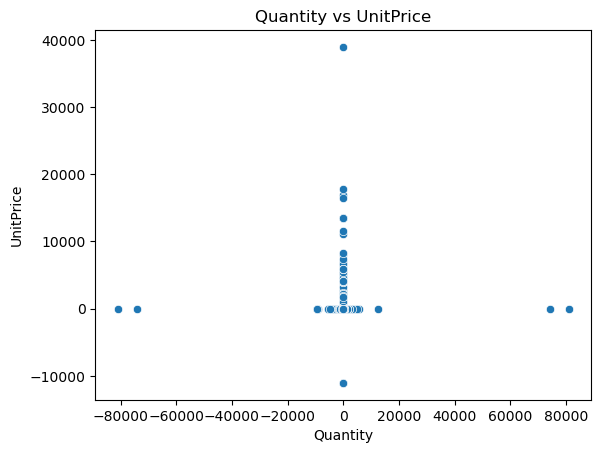

In [14]:
# Relationship between 'Quantity' and 'UnitPrice'
sns.scatterplot(x='Quantity', y='UnitPrice', data=retail)
plt.title('Quantity vs UnitPrice')
plt.show()

In [15]:
# ---- Data Quality Checking ----
# Find MISSING Values
retail.isna().sum()

InvoiceNo            0
StockCode            0
Description       1454
Quantity             0
InvoiceMonth         0
UnitPrice            0
CustomerID      135080
Country              0
dtype: int64

<Axes: ylabel='UnitPrice'>

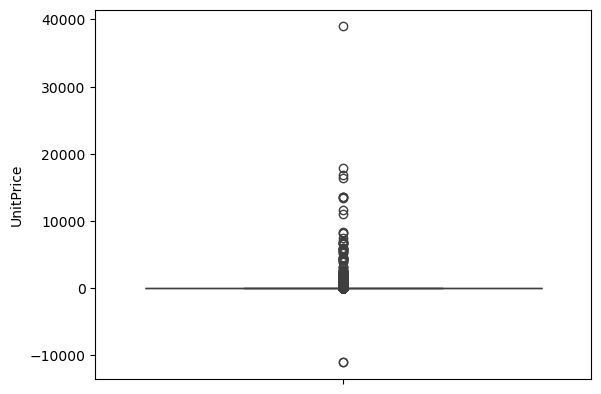

In [16]:
#Boxplot to identify outliers for "Unit Price"
sns.boxplot(data = retail['UnitPrice']) 

In [17]:
# UnitPrice: Calculate statistics of boxplot
price_Q1 = np.percentile(retail['UnitPrice'], 25)
price_Q3 = np.percentile(retail['UnitPrice'], 75)
price_IQR = price_Q3 - price_Q1
price_median = np.median(retail['UnitPrice'])
price_lower_whisker = price_Q1 - 1.5 * price_IQR
price_upper_whisker = price_Q3 + 1.5 * price_IQR
price_outliers = retail['UnitPrice'][(retail['UnitPrice'] < price_lower_whisker) | (retail['UnitPrice'] > price_upper_whisker)]

# Print the statistics
print(f"Q1: {price_Q1}")
print(f"Q3: {price_Q3}")
print(f"IQR: {price_IQR}")
print(f"Median: {price_median}")
print(f"Lower Whisker: {price_lower_whisker}")
print(f"Upper Whisker: {price_upper_whisker}")
print("Number of Outliers: " + str(len(price_outliers)))
print(f"Outliers: {price_outliers}")

Q1: 1.25
Q3: 4.13
IQR: 2.88
Median: 2.08
Lower Whisker: -3.0700000000000003
Upper Whisker: 8.45
Number of Outliers: 39627
Outliers: 16         9.95
45        18.00
65        10.95
141       27.50
151       14.95
          ...  
541768    18.00
541786    11.95
541831     8.50
541849     9.95
541892     8.95
Name: UnitPrice, Length: 39627, dtype: float64


In [18]:
#Determined the outliers again (with no negative values for "UnitPrice")
#Replace negative UnitPrice values with 0
retail['UnitPrice'] = retail['UnitPrice'].clip(lower=0)

price_Q1 = np.percentile(retail['UnitPrice'], 25)
price_Q3 = np.percentile(retail['UnitPrice'], 75)
price_IQR = price_Q3 - price_Q1
price_median = np.median(retail['UnitPrice'])
price_lower_whisker = 0  # Set lower whisker to 0
price_upper_whisker = price_Q3 + 1.5 * price_IQR
price_outliers = retail['UnitPrice'][(retail['UnitPrice'] < price_lower_whisker) | (retail['UnitPrice'] > price_upper_whisker)]

#print the statistics
print(f"Q1: {price_Q1}")
print(f"Q3: {price_Q3}")
print(f"IQR: {price_IQR}")
print(f"Median: {price_median}")
print(f"Lower Whisker: {price_lower_whisker}")
print(f"Upper Whisker: {price_upper_whisker}")
print("Number of Outliers: " + str(len(price_outliers)))
print(f"Outliers: {price_outliers}")

Q1: 1.25
Q3: 4.13
IQR: 2.88
Median: 2.08
Lower Whisker: 0
Upper Whisker: 8.45
Number of Outliers: 39625
Outliers: 16         9.95
45        18.00
65        10.95
141       27.50
151       14.95
          ...  
541768    18.00
541786    11.95
541831     8.50
541849     9.95
541892     8.95
Name: UnitPrice, Length: 39625, dtype: float64


<Axes: ylabel='Quantity'>

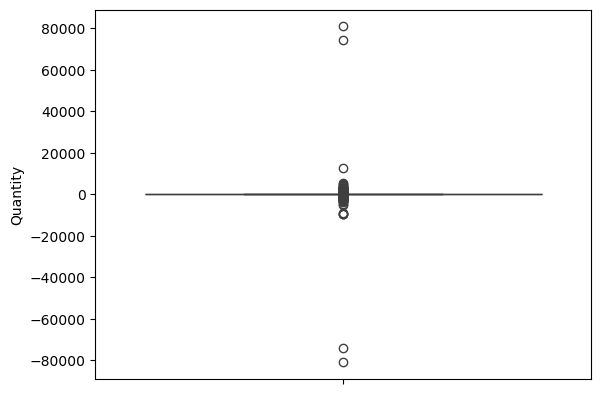

In [19]:
#Boxplot to identify outliers for "Quantity"
sns.boxplot(data = retail['Quantity'])

In [20]:
#Quantity: Calculate statistics of boxplot
qty_Q1 = np.percentile(retail['Quantity'], 25)
qty_Q3 = np.percentile(retail['Quantity'], 75)
qty_IQR = qty_Q3 - qty_Q1
qty_median = np.median(retail['Quantity'])
qty_lower_whisker = qty_Q1 - 1.5 * qty_IQR
qty_upper_whisker = qty_Q3 + 1.5 * qty_IQR
qty_outliers = retail['Quantity'][(retail['Quantity'] < qty_lower_whisker) | (retail['Quantity'] > qty_upper_whisker)]

#print the statistics
print(f"Q1: {qty_Q1}")
print(f"Q3: {qty_Q3}")
print(f"IQR: {qty_IQR}")
print(f"Median: {qty_median}")
print(f"Lower Whisker: {qty_lower_whisker}")
print(f"Upper Whisker: {qty_upper_whisker}")
print("Number of Outliers: " + str(len(qty_outliers)))
print(f"Outliers: {qty_outliers}")

Q1: 1.0
Q3: 10.0
IQR: 9.0
Median: 3.0
Lower Whisker: -12.5
Upper Whisker: 23.5
Number of Outliers: 58619
Outliers: 9         32
26        24
27        24
30        24
31        48
          ..
541876    24
541882    24
541883    25
541891    24
541892    24
Name: Quantity, Length: 58619, dtype: int64


In [21]:
# Filter rows with inconsistent descriptions
inconsistent_descriptions = retail[retail['Description'].str.contains(r'\?+|wrong', case=False, na=False)]

# Show inconsistent rows
print(inconsistent_descriptions)

       InvoiceNo StockCode      Description  Quantity  InvoiceMonth  \
7313      537032     21275                ?       -30            12   
21518     538090     20956                ?      -723            12   
38261     539494     21479                ?       752            12   
43662     540100     22837                ?      -106             1   
50806     540558     21258                ?       -29             1   
...          ...       ...              ...       ...           ...   
514649    579734    84859C             wet?      -153            11   
514735    579742     85204           lost??     -1131            11   
524370    580547     21201              ???      -390            12   
535324    581201     22217         damages?      -155            12   
535327    581204     85104  ????damages????      -355            12   

        UnitPrice  CustomerID         Country  
7313          0.0         NaN  United Kingdom  
21518         0.0         NaN  United Kingdom  
382

In [22]:
# ---- Data Cleaning ----
# Handling MISSING VALUE for "Description"
missing_desc = retail['Description'].isnull().sum()
print(f"Total Missing Description: {missing_desc}")

retail.dropna(subset=['Description'], inplace=True)

missing_desc = retail['Description'].isnull().sum()
print(f"Total Missing Description after data cleaning: {missing_desc}")

Total Missing Description: 1454
Total Missing Description after data cleaning: 0


In [23]:
#Handling MISSING VALUE for "CustomerID"

missing_cust = retail['CustomerID'].isnull().sum()
print(f"Total Missing CustomerID: {missing_cust}")

retail['CustomerID'] = retail['CustomerID'].fillna('Unknown')
# Convert CustomerID attributes value to string(object) as categorical value
retail['CustomerID'] = retail['CustomerID'].apply(lambda x: str(int(float(x))) if x != 'Unknown' else x)

missing_cust = retail['CustomerID'].isnull().sum()
print(f"Total Missing CustomerID after data cleaning: {missing_cust}")

Total Missing CustomerID: 133626
Total Missing CustomerID after data cleaning: 0


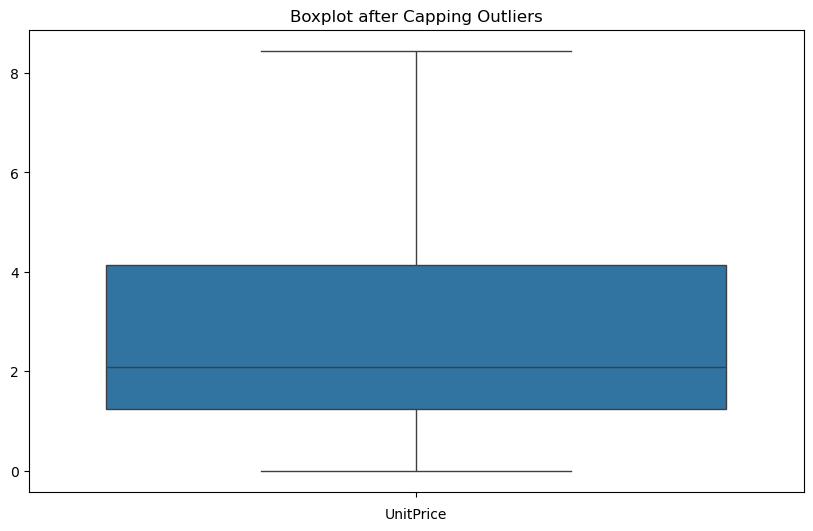

In [24]:
#Handling UnitPrice outliers: Cap or Floor Outliers
capped_data = np.copy(retail['UnitPrice'])
capped_data[capped_data > price_upper_whisker] = price_upper_whisker
capped_data[capped_data < price_lower_whisker] = price_lower_whisker

# Update the 'UnitPrice' column in the original DataFrame
retail['UnitPrice'] = capped_data

plt.figure(figsize=(10,6))
sns.boxplot(data=capped_data)
plt.title('Boxplot after Capping Outliers')
plt.xlabel('UnitPrice')
plt.show()

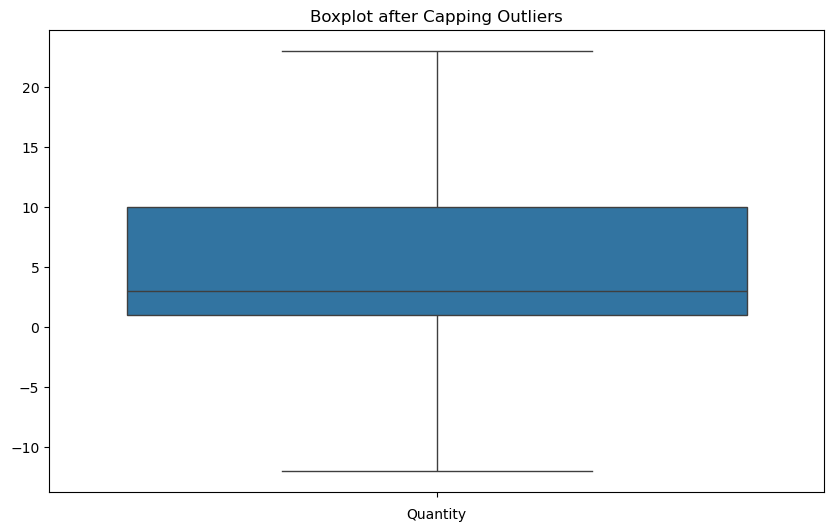

In [25]:
#Handling Quantity outliers: Cap or Floor Outliers
capped_data = np.copy(retail['Quantity'])
capped_data[capped_data > qty_upper_whisker] = qty_upper_whisker
capped_data[capped_data < qty_lower_whisker] = qty_lower_whisker

# Update the 'Quantity' column in the original DataFrame
retail['Quantity'] = capped_data

plt.figure(figsize=(10,6))
sns.boxplot(data=capped_data)
plt.title('Boxplot after Capping Outliers')
plt.xlabel('Quantity')
plt.show()

In [26]:
#Handling Ambiguous "Description"
#Replace ambiguous descriptions with "Unknown / Issue Reported"
retail['Description'] = retail['Description'].replace(r'\?+|wrong', 'Unknown / Issue Reported', regex=True)

In [27]:
# ---- Data Transformation ----
# Deriving TotalPrice attribute
retail['TotalPrice'] = retail['Quantity'] * retail['UnitPrice']
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceMonth,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12,3.39,17850,United Kingdom,20.34


In [28]:
# Ensure 'CustomerID' and 'InvoiceNo' are treated as categorical
retail['CustomerID'] = retail['CustomerID'].astype(str)
retail['InvoiceNo'] = retail['InvoiceNo'].astype(str)

# Group by 'CustomerID' to perform aggregations
customer_agg = retail.groupby('CustomerID').agg(
    TotalQuantity=('Quantity', 'sum'),      # Total quantity purchased
    TransactionNum=('InvoiceNo', 'nunique'),  # Number of invoice
    AvgPurchaseAmount=('TotalPrice', 'mean'),  # Average spending per invoice
    TotalSpent=('TotalPrice', 'sum'),       # Total amount spent
    PercentReturned=('Quantity', lambda x: (x < 0).mean() * 100)  # Percentage of returns (negative quantities)
    #Mean of the boolean value true for negative quantity
).reset_index()

print(customer_agg.head())

  CustomerID  TotalQuantity  TransactionNum  AvgPurchaseAmount  TotalSpent  \
0      12346             11               2           5.720000       11.44   
1      12347           2105               7          21.052912     3831.63   
2      12348            627               4          16.252581      503.83   
3      12349            600               1          18.541370     1353.52   
4      12350            196               1          17.764706      302.00   

   PercentReturned  
0             50.0  
1              0.0  
2              0.0  
3              0.0  
4              0.0  


In [29]:
# Save customer aggregation data before scaling
customer_agg.to_csv('customer_agg.csv', index=False)
print("Customer aggregation data saved successfully.")

Customer aggregation data saved successfully.


In [30]:
# Identify number of different product types
unique_values = retail['StockCode'].nunique()
print(f"There are {unique_values} different values in the column.")
print(retail['StockCode'].head(100))

There are 3958 different values in the column.
0     85123A
1      71053
2     84406B
3     84029G
4     84029E
       ...  
95     22352
96     21212
97     21975
98     21977
99     84991
Name: StockCode, Length: 100, dtype: object


In [31]:
unique_values = retail['Description'].nunique()
print(f"There are {unique_values} different values in the column.")
print(retail['Description'].head(100))

There are 4218 different values in the column.
0      WHITE HANGING HEART T-LIGHT HOLDER
1                     WHITE METAL LANTERN
2          CREAM CUPID HEARTS COAT HANGER
3     KNITTED UNION FLAG HOT WATER BOTTLE
4          RED WOOLLY HOTTIE WHITE HEART.
                     ...                 
95      LUNCH BOX WITH CUTLERY RETROSPOT 
96        PACK OF 72 RETROSPOT CAKE CASES
97         PACK OF 60 DINOSAUR CAKE CASES
98     PACK OF 60 PINK PAISLEY CAKE CASES
99            60 TEATIME FAIRY CAKE CASES
Name: Description, Length: 100, dtype: object


In [32]:
# Define keyword-based categorization rules
def categorize_product(description):
    description = description.lower()  # Convert to lowercase for uniformity

    if any(keyword in description for keyword in ['christmas']):
        return 'Christmas Items'
    elif any(keyword in description for keyword in ['easter']):
        return 'Easter Items'
    elif any(keyword in description for keyword in ['candle', 'lantern', 'paint', 'wall art', 'decor', 'hanging', 'hanger']):
        return 'Decorative Items'
    elif any(keyword in description for keyword in ['mug', 'cup', 'plate', 'cake', 'spoon', 'cutlery', 'baking', 'oven glove', 'apron']):
        return 'Kitchenware'
    elif any(keyword in description for keyword in ['gift', 'birthday']):
        return 'Gift Items'
    elif any(keyword in description for keyword in ['pen', 'pencil', 'card', 'envelope', 'book']):
        return 'Stationery'
    elif any(keyword in description for keyword in ['bottle', 'hot water', 'basket', 'box']):
        return 'Household Items'
    elif any(keyword in description for keyword in ['toy', 'doll', 'game', 'puzzle']):
        return 'Toys'
    elif any(keyword in description for keyword in ['bag', 'necklace', 'bracelet', 'earrings', 'clothing', 'hat', 'gloves', 'handbag']):
        return 'Fashion Acessories'
    elif any(keyword in description for keyword in ['garden', 'plant', 'outdoor', 'pot', 'watering']):
        return 'Gardening'
    else:
        return 'Other' 

# New 'Category' column
retail['Category'] = retail['Description'].apply(categorize_product)

print(retail[['Description', 'Category']])

                                Description          Category
0        WHITE HANGING HEART T-LIGHT HOLDER  Decorative Items
1                       WHITE METAL LANTERN  Decorative Items
2            CREAM CUPID HEARTS COAT HANGER  Decorative Items
3       KNITTED UNION FLAG HOT WATER BOTTLE   Household Items
4            RED WOOLLY HOTTIE WHITE HEART.             Other
...                                     ...               ...
541904          PACK OF 20 SPACEBOY NAPKINS             Other
541905         CHILDREN'S APRON DOLLY GIRL        Kitchenware
541906        CHILDRENS CUTLERY DOLLY GIRL        Kitchenware
541907      CHILDRENS CUTLERY CIRCUS PARADE       Kitchenware
541908        BAKING SET 9 PIECE RETROSPOT        Kitchenware

[540455 rows x 2 columns]


In [33]:
from sklearn.preprocessing import OneHotEncoder
# Apply one-hot encoding to 'Category'
retail = pd.get_dummies(retail, columns=['Category'], prefix='Category')

print(retail.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

   InvoiceMonth  UnitPrice CustomerID         Country  TotalPrice  \
0            12       2.55      17850  United Kingdom       15.30   
1            12       3.39      17850  United Kingdom       20.34   
2            12       2.75      17850  United Kingdom       22.00   
3            12       3.39      17850  United Kingdom       20.34   
4            12       3.39      17850  United Kingdom       20.34   

   Category_Christmas Items  Category_Decorative Items  Category_Easter Items  \
0                     False                       True                 

In [34]:
# Drop off InvoiceNo attribute
cols = retail[['InvoiceNo']]
retail=retail.drop(cols,axis=1)
retail.head()

,StockCode,Description,Quantity,InvoiceMonth,UnitPrice,CustomerID,Country,TotalPrice,Category_Christmas Items,Category_Decorative Items,Category_Easter Items,Category_Fashion Acessories,Category_Gardening,Category_Gift Items,Category_Household Items,Category_Kitchenware,Category_Other,Category_Stationery,Category_Toys
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12,2.55,17850,United Kingdom,15.30,False,True,False,False,False,False,False,False,False,False,False
1,71053,WHITE METAL LANTERN,6,12,3.39,17850,United Kingdom,20.34,False,True,False,False,False,False,False,False,False,False,False
2,84406B,CREAM CUPID HEARTS COAT HANGER,8,12,2.75,17850,United Kingdom,22.00,False,True,False,False,False,False,False,False,False,False,False
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12,3.39,17850,United Kingdom,20.34,False,False,False,False,False,False,True,False,False,False,False
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12,3.39,17850,United Kingdom,20.34,False,False,False,False,False,False,False,False,True,False,False


In [35]:
# Scale data
from sklearn.preprocessing import StandardScaler

# Columns that need scaling
columns_to_scale = ['TotalQuantity', 'TransactionNum', 'AvgPurchaseAmount', 'TotalSpent', 'PercentReturned']

scaler = StandardScaler()
# Fit and transform the data
scaled_data = scaler.fit_transform(customer_agg[columns_to_scale])
customer_agg[columns_to_scale] = scaled_data

print(customer_agg.head())

  CustomerID  TotalQuantity  TransactionNum  AvgPurchaseAmount  TotalSpent  \
0      12346      -0.140010       -0.101729          -0.847128   -0.087829   
1      12347       0.232353        0.039946           0.277998    0.124930   
2      12348      -0.030470       -0.045059          -0.074249   -0.060406   
3      12349      -0.035272       -0.130064           0.093702   -0.013084   
4      12350      -0.107112       -0.130064           0.036710   -0.071647   

   PercentReturned  
0         4.374317  
1        -0.299485  
2        -0.299485  
3        -0.299485  
4        -0.299485  


In [36]:
# Transform 'Country' into 'United Kingdom' and 'Other'
retail['Country'] = retail['Country'].apply(lambda x: 'United Kingdom' if x == 'United Kingdom' else 'Other')

# Apply one-hot encoding to the 'Country' feature
encoder = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' to avoid multicollinearity
encoded_country = encoder.fit_transform(retail[['Country']])

# Convert the encoded data to a DataFrame and merge back into the original retail DataFrame
encoded_country_df = pd.DataFrame(encoded_country, columns=encoder.get_feature_names_out(['Country']), index=retail.index)

retail = pd.concat([retail, encoded_country_df], axis=1)
retail.drop('Country', axis=1, inplace=True)

print(retail.head())

  StockCode                          Description  Quantity  InvoiceMonth  \
0    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6            12   
1     71053                  WHITE METAL LANTERN         6            12   
2    84406B       CREAM CUPID HEARTS COAT HANGER         8            12   
3    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6            12   
4    84029E       RED WOOLLY HOTTIE WHITE HEART.         6            12   

   UnitPrice CustomerID  TotalPrice  Category_Christmas Items  \
0       2.55      17850       15.30                     False   
1       3.39      17850       20.34                     False   
2       2.75      17850       22.00                     False   
3       3.39      17850       20.34                     False   
4       3.39      17850       20.34                     False   

   Category_Decorative Items  Category_Easter Items  \
0                       True                  False   
1                       True              

In [37]:
# ---- Feature Selection ----
# Drop CustomerID, StockCode, and Description 
customer_ids= retail['CustomerID']
features=retail.drop(['CustomerID'],axis=1)

cols=['StockCode','Description']
features=features.drop(columns=cols,axis=1)

print(features.dtypes)

Quantity                         int64
InvoiceMonth                     int64
UnitPrice                      float64
TotalPrice                     float64
Category_Christmas Items          bool
Category_Decorative Items         bool
Category_Easter Items             bool
Category_Fashion Acessories       bool
Category_Gardening                bool
Category_Gift Items               bool
Category_Household Items          bool
Category_Kitchenware              bool
Category_Other                    bool
Category_Stationery               bool
Category_Toys                     bool
Country_United Kingdom         float64
dtype: object


In [38]:
# Scale data for selected features 
from sklearn.impute import SimpleImputer

scaled_features = scaler.fit_transform(features)

# Create an imputer object with a strategy
imputer = SimpleImputer(strategy='mean')  # Or use 'median', 'most_frequent', etc.
scaled_features = imputer.fit_transform(scaled_features)
scaled_features_df=pd.DataFrame(scaled_features, columns=features.columns)

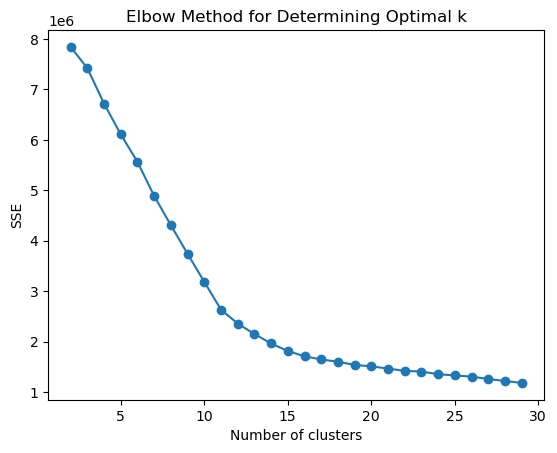

In [39]:
# ---- KMeans Modelling ----
# Elbow Method to determine number of cluster
from sklearn.cluster import KMeans 
sse={}
for k in range(2,30):
    kmeans=KMeans(n_clusters=k,n_init=10,init="k-means++",random_state=50)
    kmeans.fit(scaled_features_df)
    sse[k]=kmeans.inertia_

plt.plot(list(sse.keys()), list(sse.values()), marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.title("Elbow Method for Determining Optimal k")
plt.show()

In [40]:
# Silhouette Score 
from sklearn.metrics import silhouette_score

scaled_features_df = pd.DataFrame(scaled_features_df)

# Sample from the DataFrame
sample_size = min(50000, len(scaled_features_df))  
sample_data = scaled_features_df.sample(n=sample_size, random_state=42)

silhouette_scores = []
for k in range(2, 30):  # start from 2 clusters, as silhouette score is undefined for k=1
    kmeans = KMeans(n_clusters=k, n_init=10, init="k-means++",random_state=42)  # Reduced n_init
    cluster_labels = kmeans.fit_predict(sample_data)
    silhouette_avg = silhouette_score(sample_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Number of clusters: {k}, Silhouette Score: {silhouette_avg}")

Number of clusters: 2, Silhouette Score: 0.15595317527377117
Number of clusters: 3, Silhouette Score: 0.1667902756456316
Number of clusters: 4, Silhouette Score: 0.24013079474356466
Number of clusters: 5, Silhouette Score: 0.26722707114114064
Number of clusters: 6, Silhouette Score: 0.2949957699369894
Number of clusters: 7, Silhouette Score: 0.36220553662067534
Number of clusters: 8, Silhouette Score: 0.35552594478274235
Number of clusters: 9, Silhouette Score: 0.42256912599471186
Number of clusters: 10, Silhouette Score: 0.46418872434137026
Number of clusters: 11, Silhouette Score: 0.47434679843992716
Number of clusters: 12, Silhouette Score: 0.41597769505144555
Number of clusters: 13, Silhouette Score: 0.417132953993419
Number of clusters: 14, Silhouette Score: 0.4046537039641716
Number of clusters: 15, Silhouette Score: 0.4142252485709611
Number of clusters: 16, Silhouette Score: 0.416913751765385
Number of clusters: 17, Silhouette Score: 0.4173838006410734
Number of clusters: 18, S

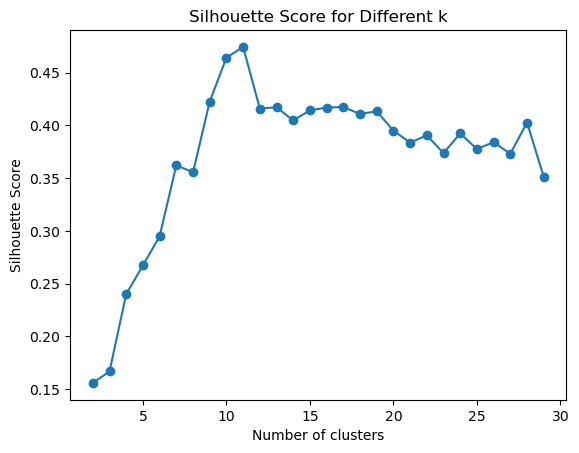

In [41]:
# Plot the silhouette scores
plt.plot(range(2, 30), silhouette_scores, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k")
plt.show()

In [42]:
# ---- Hyperparameter Tuning ----
from sklearn.model_selection import ParameterGrid

sample_size = min(50000, len(scaled_features_df))  # Sample of size 50 000
sample_data = scaled_features_df.sample(n=sample_size, random_state=42)

# Define parameter grid
param_grid = {
    'n_clusters': [10,11],
    'n_init': [10, 15, 20,25]
}

In [43]:
results = []
best_params = None
best_score = -1

# Evaluate different parameter combinations
for params in ParameterGrid(param_grid):
    kmeans = KMeans(n_clusters=params['n_clusters'], n_init=params['n_init'], init="k-means++",random_state=42)
    cluster_labels = kmeans.fit_predict(sample_data)
    silhouette_avg = silhouette_score(sample_data, cluster_labels)
    
    results.append({
        'n_clusters': params['n_clusters'],
        'n_init': params['n_init'],
        'silhouette_score': silhouette_avg
    })
    
    # Track best parameters
    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_params = params

results_df = pd.DataFrame(results)

print("Hyperparameter Tuning Results:")
for result in results:
    print(result)

Hyperparameter Tuning Results:
{'n_clusters': 10, 'n_init': 10, 'silhouette_score': 0.46418872434137026}
{'n_clusters': 10, 'n_init': 15, 'silhouette_score': 0.4604306615117399}
{'n_clusters': 10, 'n_init': 20, 'silhouette_score': 0.4604306615117399}
{'n_clusters': 10, 'n_init': 25, 'silhouette_score': 0.4604306615117399}
{'n_clusters': 11, 'n_init': 10, 'silhouette_score': 0.47434679843992716}
{'n_clusters': 11, 'n_init': 15, 'silhouette_score': 0.47434679843992716}
{'n_clusters': 11, 'n_init': 20, 'silhouette_score': 0.47434679843992716}
{'n_clusters': 11, 'n_init': 25, 'silhouette_score': 0.47434679843992716}


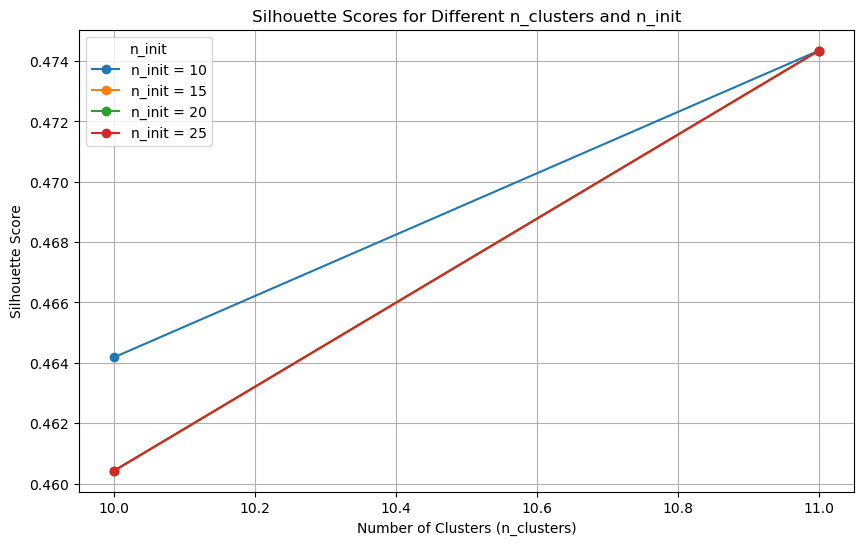

In [44]:
# Plot the silhouette scores for different n_clusters and n_init combinations
plt.figure(figsize=(10, 6))

# Plotting silhouette scores for each n_clusters
for n_init in results_df['n_init'].unique():
    subset = results_df[results_df['n_init'] == n_init]
    plt.plot(subset['n_clusters'], subset['silhouette_score'], marker='o', label=f'n_init = {n_init}')

plt.title('Silhouette Scores for Different n_clusters and n_init')
plt.xlabel('Number of Clusters (n_clusters)')
plt.ylabel('Silhouette Score')
plt.legend(title="n_init")
plt.grid(True)
plt.show()


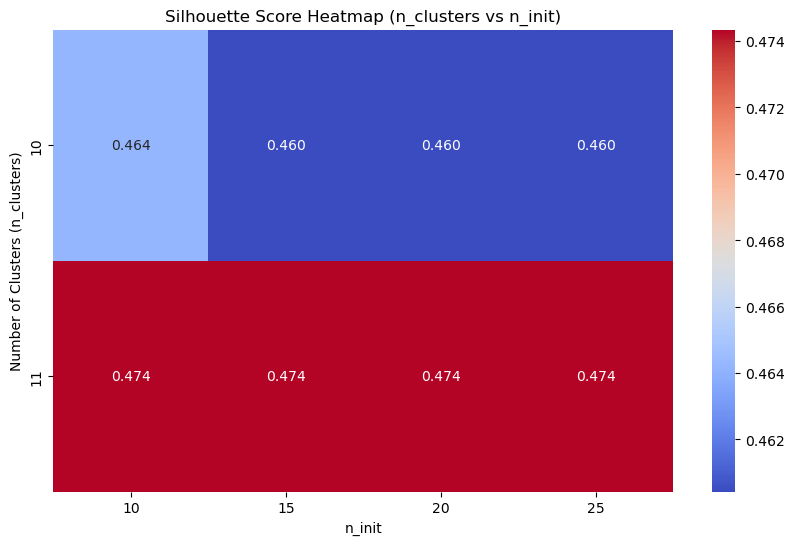

In [45]:
# Pivot the data for a heatmap (Silhouette Score by n_clusters and n_init)
heatmap_data = results_df.pivot(index="n_clusters", columns="n_init", values="silhouette_score")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap='coolwarm')
plt.title('Silhouette Score Heatmap (n_clusters vs n_init)')
plt.xlabel('n_init')
plt.ylabel('Number of Clusters (n_clusters)')
plt.show()

In [46]:
# Display the Best Hyperparameters
print("\nBest Hyperparameters:")
print(f"Number of clusters: {best_params['n_clusters']}")
print(f"n_init: {best_params['n_init']}")
print(f"Best Silhouette Score: {best_score}")


Best Hyperparameters:
Number of clusters: 11
n_init: 10
Best Silhouette Score: 0.47434679843992716


In [47]:
# Best parameters
best_n_clusters = best_params['n_clusters']
best_n_init = best_params['n_init']

# Train final model
final_kmeans = KMeans(n_clusters=best_n_clusters, n_init=best_n_init,init="k-means++", random_state=42)
final_labels = final_kmeans.fit_predict(scaled_features_df)

In [48]:
# Calculate cluster distribution
unique, counts = np.unique(final_labels, return_counts=True)
cluster_distribution = dict(zip(unique, counts))
sorted_cluster_distribution = dict(sorted(cluster_distribution.items(), key=lambda item: item[1], reverse=True))
print("Cluster Distribution :")
for cluster, count in sorted_cluster_distribution.items():
    print(f"Cluster {cluster}: {count} ")

Cluster Distribution :
Cluster 5: 236533 
Cluster 2: 59510 
Cluster 6: 51207 
Cluster 0: 47798 
Cluster 3: 34108 
Cluster 10: 32184 
Cluster 8: 31572 
Cluster 1: 25132 
Cluster 9: 10288 
Cluster 7: 9689 
Cluster 4: 2434 


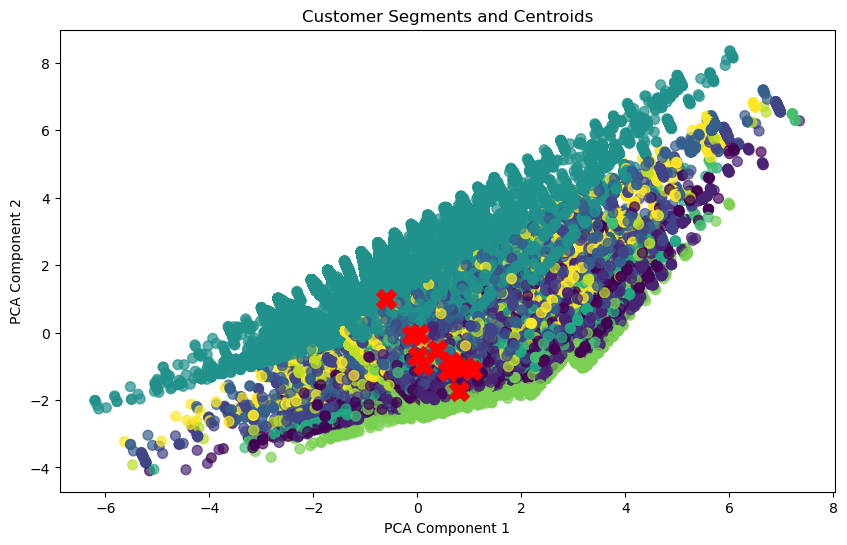

In [49]:
from sklearn.decomposition import PCA

# Fit PCA on the original scaled features
pca = PCA(n_components=2)
reduced_pca = pca.fit_transform(scaled_features_df)

# Convert centroids to a DataFrame with the same columns as scaled_features_df
centroids_df = pd.DataFrame(final_kmeans.cluster_centers_, columns=scaled_features_df.columns)

# Transform centroids using PCA
centroids_pca = pca.transform(centroids_df)

# Plot the clusters and centroids
plt.figure(figsize=(10, 6))
plt.scatter(reduced_pca[:, 0], reduced_pca[:, 1], c=final_labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=200, marker='X')  # Plot centroids
plt.title('Customer Segments and Centroids')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [50]:
retail['Cluster']=final_kmeans.labels_
customer_clusters = retail[['CustomerID', 'Cluster']].drop_duplicates()

In [51]:
cluster_profiles=retail.groupby('Cluster').mean(numeric_only=True)
# Rounding and converting specific columns to integers for categories
categories = ['Quantity', 'InvoiceMonth', 'Category_Christmas Items', 'Category_Decorative Items', 
              'Category_Easter Items', 'Category_Fashion Acessories', 'Category_Gardening', 
              'Category_Gift Items', 'Category_Household Items', 'Category_Kitchenware', 
              'Category_Other', 'Category_Stationery', 'Category_Toys']

for category in categories:
    cluster_profiles[category] = cluster_profiles[category].round().astype(int)

# Formatting UnitPrice and TotalPrice to two decimal places
cluster_profiles['UnitPrice'] = cluster_profiles['UnitPrice'].round(2)
cluster_profiles['TotalPrice'] = cluster_profiles['TotalPrice'].round(2)

if 'Country_United Kingdom' in cluster_profiles.columns:
    cluster_profiles['Country_United Kingdom'] = cluster_profiles['Country_United Kingdom'].round()
print('Cluster Profile: ')
print(cluster_profiles)
print(customer_clusters.head(20)) 

Cluster Profile: 
         Quantity  InvoiceMonth  UnitPrice  TotalPrice  \
Cluster                                                  
0               7             8       2.35       11.76   
1               8            10       2.17       12.85   
2               6             7       3.09       13.10   
3               5             8       3.82       16.36   
4               6             3       2.08        9.44   
5               6             7       3.24       13.03   
6               7             7       2.45       13.44   
7               9             7       2.01        9.17   
8               8             8       1.56        7.82   
9               5             8       3.03       11.87   
10              6             7       3.82       14.64   

         Category_Christmas Items  Category_Decorative Items  \
Cluster                                                        
0                               0                          1   
1                               1  

In [52]:
# Testing EUCLIDEAN DISTANCE METRIC

# Define the function to compute silhouette score with a given distance metric
def compute_silhouette(metric, X, k):
    print(f"Computing silhouette score for metric: {metric}")
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=50)
    kmeans.fit(X)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X, labels, metric=metric)
    print(f"Completed metric: {metric}, Silhouette Score: {silhouette_avg}")
    return silhouette_avg

# Sample the data that is too large
sample_size = min(50000, len(scaled_features_df))  # Sample of 50 000
sample_data = scaled_features_df.sample(n=sample_size, random_state=42)

# Test for Euclidean distance
k = best_params['n_clusters']
silhouette_scores = {}
euclidean_silhouette = compute_silhouette('euclidean', sample_data, k)
silhouette_scores['euclidean'] = euclidean_silhouette
print(f"Euclidean Distance - Silhouette Score: {euclidean_silhouette}")

Computing silhouette score for metric: euclidean
Completed metric: euclidean, Silhouette Score: 0.44775432947189225
Euclidean Distance - Silhouette Score: 0.44775432947189225


In [53]:
# Testing MANHATTAN DISTANCE METRIC

# Test for Manhattan distance
k = best_params['n_clusters']
manhattan_silhouette = compute_silhouette('manhattan', sample_data, k)
silhouette_scores['manhattan'] = manhattan_silhouette
print(f"Manhattan Distance - Silhouette Score: {manhattan_silhouette}")

Computing silhouette score for metric: manhattan
Completed metric: manhattan, Silhouette Score: 0.5381878331352504
Manhattan Distance - Silhouette Score: 0.5381878331352504


In [54]:
# Testing COSINE DISTANCE METRIC

# Test for Cosine distance
k = best_params['n_clusters']
cosine_silhouette = compute_silhouette('cosine', sample_data, k)
silhouette_scores['cosine'] = cosine_silhouette
print(f"Cosine Distance - Silhouette Score: {cosine_silhouette}")

Computing silhouette score for metric: cosine
Completed metric: cosine, Silhouette Score: 0.5781687488181796
Cosine Distance - Silhouette Score: 0.5781687488181796


In [55]:
# Find the best metric based on the highest silhouette score
best_metric = max(silhouette_scores, key=silhouette_scores.get)
best_score = silhouette_scores[best_metric]

# Print the best metric and its silhouette score
print(f"\nBest Distance Metric: {best_metric}")
print(f"Best Silhouette Score: {best_score}")

# Optional: Print all metrics and their scores for reference
print("\nAll Distance Metrics and Scores:")
for metric, score in silhouette_scores.items():
    print(f"{metric}: {score}")


Best Distance Metric: cosine
Best Silhouette Score: 0.5781687488181796

All Distance Metrics and Scores:
euclidean: 0.44775432947189225
manhattan: 0.5381878331352504
cosine: 0.5781687488181796


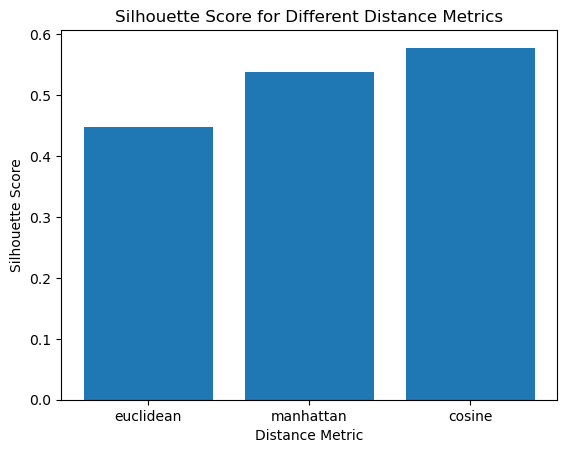

In [56]:
# Store the results in a dictionary
distance_results = {
    'euclidean': euclidean_silhouette,
    'manhattan': manhattan_silhouette,
    'cosine': cosine_silhouette
}

# Plot distance metric results
metrics = list(distance_results.keys())
scores = list(distance_results.values())

plt.bar(metrics, scores)
plt.xlabel('Distance Metric')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Distance Metrics')
plt.show()

In [57]:
# ---- Cosine Kmeans ----
import faiss
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.utils import resample
from collections import Counter

sample_size = min(50000, len(scaled_features_df))  # Sample of 50 000
sample_data = scaled_features_df.sample(n=sample_size, random_state=50)
X_normalized = normalize(sample_data)
n_clusters = best_params['n_clusters']

# Set up faiss KMeans with cosine distance
d = X_normalized.shape[1]  # Dimensionality of data

# Using inner product (cosine similarity)
kmeans = faiss.Kmeans(d, n_clusters, niter=20, spherical=True)  # spherical=True ensures cosine distance

# Train KMeans on the normalized data
kmeans.train(X_normalized.astype(np.float32))

# Get the cluster centroids and labels
centroids = kmeans.centroids
D, labels = kmeans.index.search(X_normalized.astype(np.float32), 1)


In [58]:
# Analyze the cluster distribution
labels = labels.ravel()  # Flatten the labels to a 1D array
cluster_sizes = Counter(labels)

# Sort the cluster sizes in descending order
sorted_cluster_sizes = sorted(cluster_sizes.items(), key=lambda item: item[1], reverse=True)

# Print the sorted cluster sizes
print("Cluster Sizes Distribution (Descending):")
for cluster, size in sorted_cluster_sizes:
    print(f"Cluster {cluster}: {size} points")
    

Cluster Sizes Distribution (Descending):
Cluster 7: 6360 points
Cluster 5: 5709 points
Cluster 1: 5537 points
Cluster 8: 5464 points
Cluster 2: 5369 points
Cluster 10: 5066 points
Cluster 0: 4707 points
Cluster 3: 4353 points
Cluster 4: 3231 points
Cluster 6: 2986 points
Cluster 9: 1218 points


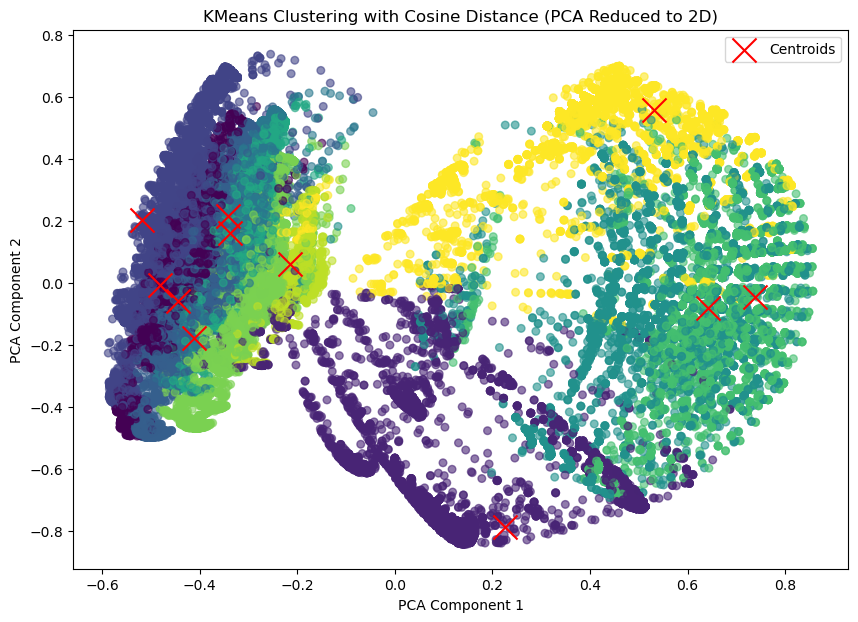

In [59]:
# PCA to reduce dimensions for visualization (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

# Apply PCA on the centroids as well for plotting
centroids_pca = pca.transform(centroids)

# Plot the clusters and centroids in 2D
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=30, alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='x', label='Centroids')  # Centroids
plt.title("KMeans Clustering with Cosine Distance (PCA Reduced to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [60]:
# Add Cluster Labels to Sampled Data
sample_data_with_labels = sample_data.copy()
sample_data_with_labels['Cluster_Cosine'] = labels  # Assign the cluster labels to the sampled data

# Merge the cluster labels back into the original dataset using the index
scaled_features_df_with_clusters_cosinekmeans = pd.merge(scaled_features_df, 
                                            sample_data_with_labels[['Cluster_Cosine']], 
                                            how='left', 
                                            left_index=True, 
                                            right_index=True)
# Create cluster profiles for cosine KMeans
cluster_profiles_cosinekmeans = scaled_features_df_with_clusters_cosinekmeans.groupby('Cluster_Cosine').mean(numeric_only=True)

# Extract the customer clusters for cosine KMeans
customer_clusters_cosinekmeans = retail[['CustomerID']].drop_duplicates().merge(
    sample_data_with_labels[['Cluster_Cosine']], 
    how='left', 
    left_index=True, 
    right_index=True
)
customer_clusters_cosinekmeans['Cluster_Cosine'] = customer_clusters_cosinekmeans['Cluster_Cosine'].fillna(-1, inplace=False)
filtered_customer_clusters = customer_clusters_cosinekmeans[customer_clusters_cosinekmeans['Cluster_Cosine'] != -1.0]
customer_clusters_cosinekmeans = filtered_customer_clusters

In [61]:
# Displaying Cluster Profiles
print("\nCluster Profiles:")
print(cluster_profiles_cosinekmeans)

# Displaying Customer Clusters
print("\nCustomer Clusters:")
print(customer_clusters_cosinekmeans.head(30))



Cluster Profiles:
                Quantity  InvoiceMonth  UnitPrice  TotalPrice  \
Cluster_Cosine                                                  
0.0             0.046381     -0.083516  -0.221456    0.027557   
1.0             1.430189     -0.004962  -0.520199    0.834572   
2.0            -0.036444     -0.129567   0.063063   -0.019225   
3.0             0.089815      0.007314  -0.264523   -0.075911   
4.0            -0.138439      0.182089   0.367999    0.200907   
5.0            -0.422062     -1.104554  -0.325401   -0.380277   
6.0            -0.152768     -0.191680   0.387846    0.122796   
7.0            -0.511017      0.854027  -0.308325   -0.431341   
8.0             0.202970      0.392405  -0.482309   -0.198528   
9.0            -0.151422     -0.175269  -0.044626   -0.107629   
10.0           -0.591440     -0.039729   1.827292    0.171437   

                Category_Christmas Items  Category_Decorative Items  \
Cluster_Cosine                                                  

In [62]:
silhouette_avg = silhouette_score(X_normalized, labels)
print(f"Silhouette Score: {silhouette_avg:}")

Silhouette Score: 0.40896898320032493


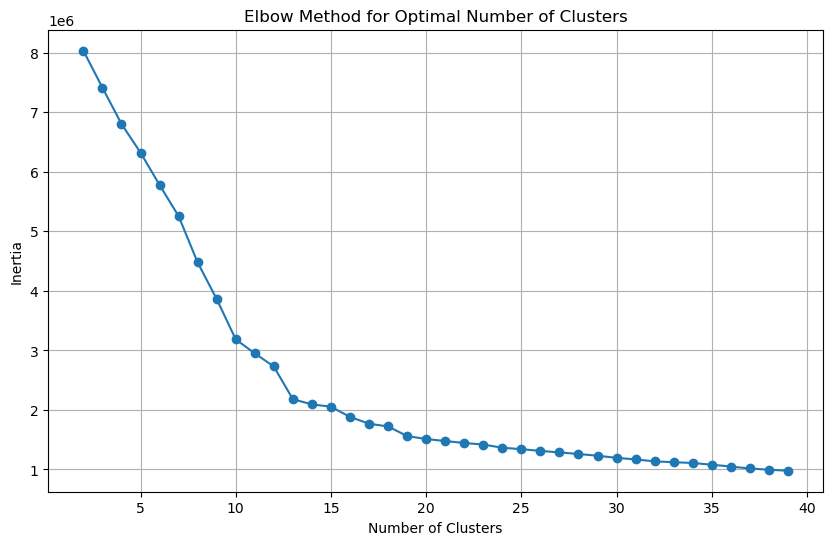

In [63]:
# ---- MiniBatchKMeans ----
#Elbow Method To get the number of clusters
from sklearn.cluster import MiniBatchKMeans
# Define a range of cluster numbers to test
cluster_range = range(2, 40)  
inertia_values = []

for n_clusters in cluster_range:
    model = MiniBatchKMeans(n_clusters=n_clusters, batch_size=5000, random_state=42)
    model.fit(scaled_features_df)  # Your scaled feature data
    inertia_values.append(model.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [64]:
# Define a range of cluster numbers to test
inertia_values = []
silhouette_scores = []

# Sample the data that is too large
sample_size = min(40000, len(scaled_features_df))  # Sample of 40 000
sample_data = scaled_features_df.sample(n=sample_size, random_state=42)

for n_clusters in range(2, 40):
    # Initialize and fit the model
    model = MiniBatchKMeans(n_clusters=n_clusters, batch_size=5000, random_state=42)
    cluster_labels = model.fit_predict(sample_data)  # Scaled feature data
    
    # Compute inertia
    inertia = model.inertia_
    inertia_values.append(inertia)
    
    silhouette_avg = silhouette_score(sample_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Number of clusters: {n_clusters}, Silhouette Score: {silhouette_avg}")


Number of clusters: 2, Silhouette Score: 0.20233298961884796
Number of clusters: 3, Silhouette Score: 0.18095208346333103
Number of clusters: 4, Silhouette Score: 0.2270364146347876
Number of clusters: 5, Silhouette Score: 0.27873107224012206
Number of clusters: 6, Silhouette Score: 0.30033694464316596
Number of clusters: 7, Silhouette Score: 0.34206329975204236
Number of clusters: 8, Silhouette Score: 0.362496729020083
Number of clusters: 9, Silhouette Score: 0.38850839995963027
Number of clusters: 10, Silhouette Score: 0.44625299196969
Number of clusters: 11, Silhouette Score: 0.4701051666611889
Number of clusters: 12, Silhouette Score: 0.4753845104743485
Number of clusters: 13, Silhouette Score: 0.39378790865340574
Number of clusters: 14, Silhouette Score: 0.39385038525476457
Number of clusters: 15, Silhouette Score: 0.3997872371991859
Number of clusters: 16, Silhouette Score: 0.4074853294669331
Number of clusters: 17, Silhouette Score: 0.4169357001945675
Number of clusters: 18, Sil

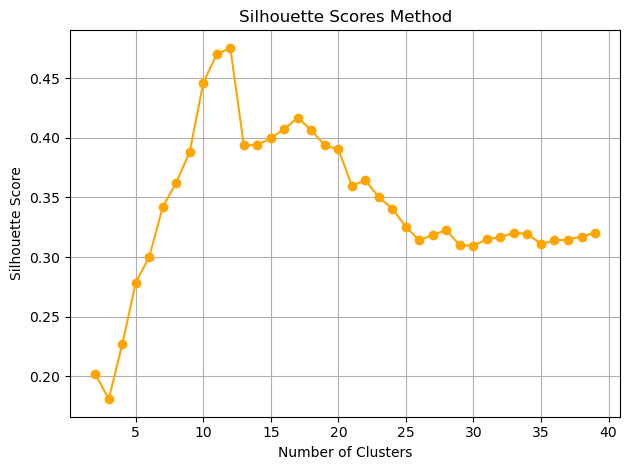

In [65]:
# Plotting Silhouette Scores
plt.plot(cluster_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Scores Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [66]:
# ---- Hyperparameter Tuning ----
from sklearn.model_selection import ParameterGrid

# Sample the data that is too large
sample_size = min(50000, len(scaled_features_df))  # Sample of 50 000
sample_data = scaled_features_df.sample(n=sample_size, random_state=42)

# Define hyperparameters to tune
param_grid = {
    'n_clusters': [8,9,10,11,12,13,14],
    'batch_size': [2500,5000,10000,15000]
}


In [67]:
# Function to evaluate MiniBatch K-Means with given parameters
def evaluate_mini_batch_kmeans(n_clusters, batch_size):
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=batch_size, random_state=42)
    kmeans.fit(sample_data)
    labels = kmeans.labels_
    inertia = kmeans.inertia_
    silhouette_avg = silhouette_score(sample_data, labels)
    return inertia, silhouette_avg

In [68]:
# Iterate over all combinations of hyperparameters
results = []
for params in ParameterGrid(param_grid):
    inertia, silhouette_avg = evaluate_mini_batch_kmeans(params['n_clusters'], params['batch_size'])
    results.append({
        'n_clusters': params['n_clusters'],
        'batch_size': params['batch_size'],
        'inertia': inertia,
        'silhouette_score': silhouette_avg
    })

In [69]:
results_df = pd.DataFrame(results)
print(results_df)

    n_clusters  batch_size        inertia  silhouette_score
0            8        2500  469711.605317          0.300774
1            9        2500  379938.362632          0.379254
2           10        2500  310340.210693          0.444846
3           11        2500  274801.426104          0.371199
4           12        2500  219857.909035          0.406109
5           13        2500  215916.766808          0.380570
6           14        2500  199221.095940          0.358980
7            8        5000  409451.556390          0.382095
8            9        5000  411422.138003          0.341890
9           10        5000  379436.434170          0.263443
10          11        5000  302836.902600          0.348156
11          12        5000  222776.043958          0.408720
12          13        5000  202193.519693          0.408727
13          14        5000  181309.369787          0.415075
14           8       10000  437028.899261          0.377095
15           9       10000  376117.83264

In [70]:
# Find the best parameters based on silhouette score (or inertia)
best_params = results_df.loc[results_df['silhouette_score'].idxmax()]
print("\nBest Parameters:")
print(best_params)


Best Parameters:
n_clusters              10.000000
batch_size            2500.000000
inertia             310340.210693
silhouette_score         0.444846
Name: 2, dtype: float64


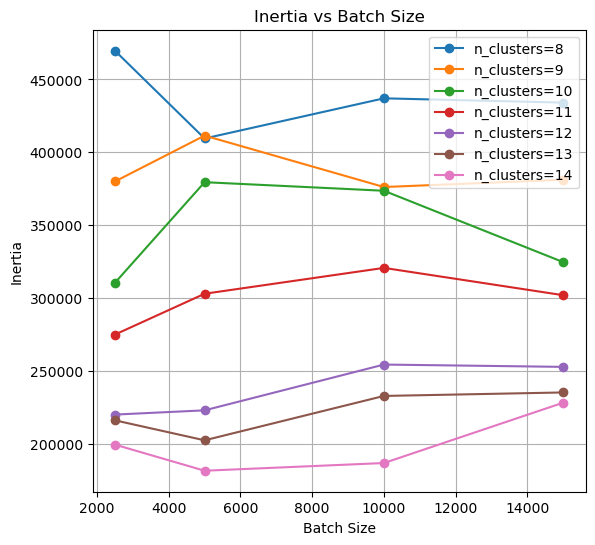

In [71]:
# Plot Silhouette Score and Inertia
plt.figure(figsize=(14, 6))

# Plot Inertia
plt.subplot(1, 2, 1)
for n_clusters in param_grid['n_clusters']:
    subset = results_df[results_df['n_clusters'] == n_clusters]
    plt.plot(subset['batch_size'], subset['inertia'], marker='o', label=f'n_clusters={n_clusters}')
plt.title('Inertia vs Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True)


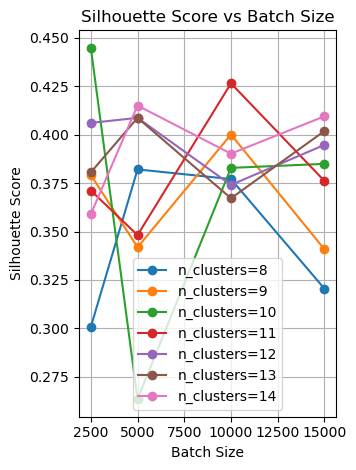

In [72]:
# Plot Silhouette Score
plt.subplot(1, 2, 2)
for n_clusters in param_grid['n_clusters']:
    subset = results_df[results_df['n_clusters'] == n_clusters]
    plt.plot(subset['batch_size'], subset['silhouette_score'], marker='o', label=f'n_clusters={n_clusters}')
plt.title('Silhouette Score vs Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [73]:
best_n_clusters = best_params['n_clusters']
best_batch_size = best_params['batch_size']

# Initialize and fit the model with the best parameters
final_minikmean = MiniBatchKMeans(n_clusters=int(best_n_clusters), batch_size=int(best_batch_size), random_state=42)
final_minikmean.fit(scaled_features_df)

# Obtain final cluster labels
final_minilabels = final_minikmean.labels_
centroids = final_minikmean.cluster_centers_

In [74]:
# Create a DataFrame from scaled features with cluster labels
retails = pd.DataFrame(scaled_features_df, columns=features.columns)

cluster_labels = final_minikmean.labels_
cluster_distribution = pd.Series(cluster_labels).value_counts()
print("Cluster Distribution:\n", cluster_distribution)

Cluster Distribution:
 1    238967
2     59510
3     51207
7     47798
4     34108
6     32184
8     31572
5     25132
9     10288
0      9689
Name: count, dtype: int64


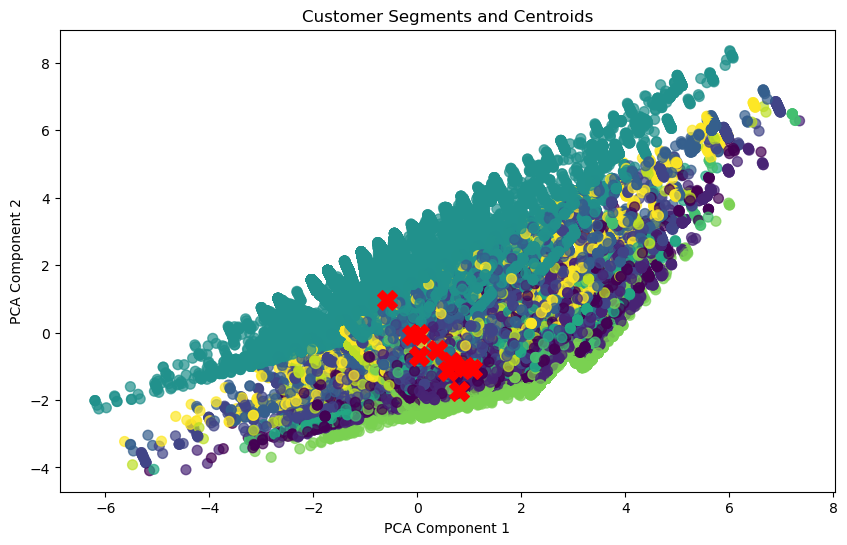

In [75]:
pca = PCA(n_components=2)
reduced_pca = pca.fit_transform(scaled_features_df)

# Convert centroids to a DataFrame with the same columns as scaled_features_df
centroids_df = pd.DataFrame(final_minikmean.cluster_centers_, columns=scaled_features_df.columns)

# Transform centroids using PCA
centroids_pca = pca.transform(centroids_df)

plt.figure(figsize=(10, 6))
plt.scatter(reduced_pca[:, 0], reduced_pca[:, 1], c=final_labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=200, marker='X')  # Plot centroids
plt.title('Customer Segments and Centroids')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [76]:
retail['Cluster'] = final_minikmean.labels_
customer_clusters_minikmean = retail[['CustomerID', 'Cluster']].drop_duplicates()

In [77]:
cluster_profiles_minikmean =retail.groupby('Cluster').mean(numeric_only=True)
categories = ['Quantity', 'InvoiceMonth', 'Category_Christmas Items', 'Category_Decorative Items', 
              'Category_Easter Items', 'Category_Fashion Acessories', 'Category_Gardening', 
              'Category_Gift Items', 'Category_Household Items', 'Category_Kitchenware', 
              'Category_Other', 'Category_Stationery', 'Category_Toys']

for category in categories:
    cluster_profiles_minikmean[category] = cluster_profiles_minikmean[category].round().astype(int)

# Formatting UnitPrice and TotalPrice to two decimal places
cluster_profiles_minikmean['UnitPrice'] = cluster_profiles_minikmean['UnitPrice'].round(2)
cluster_profiles_minikmean['TotalPrice'] = cluster_profiles_minikmean['TotalPrice'].round(2)

if 'Country_United Kingdom' in cluster_profiles.columns:
    cluster_profiles_minikmean['Country_United Kingdom'] = cluster_profiles_minikmean['Country_United Kingdom'].round()
    
print('Cluster Profile: ')
print(cluster_profiles_minikmean)
print(customer_clusters_minikmean.head(20)) 

Cluster Profile: 
         Quantity  InvoiceMonth  UnitPrice  TotalPrice  \
Cluster                                                  
0               9             7       2.01        9.17   
1               6             7       3.23       13.00   
2               6             7       3.09       13.10   
3               7             7       2.45       13.44   
4               5             8       3.82       16.36   
5               8            10       2.17       12.85   
6               6             7       3.82       14.64   
7               7             8       2.35       11.76   
8               8             8       1.56        7.82   
9               5             8       3.03       11.87   

         Category_Christmas Items  Category_Decorative Items  \
Cluster                                                        
0                               0                          0   
1                               0                          0   
2                            

In [78]:
# Testing EUCLIDEAN DISTANCE METRIC

# Sample the data that is too large
sample_size = min(50000, len(scaled_features_df))  # Sample of 50 000
sample_data = scaled_features_df.sample(n=sample_size, random_state=42)

# Test for Euclidean distance
k = int(best_n_clusters)
silhouette_scores = {}
euclidean_silhouette = compute_silhouette('euclidean', sample_data, k)
silhouette_scores['euclidean'] = euclidean_silhouette
print(f"Euclidean Distance - Silhouette Score: {euclidean_silhouette}")

Computing silhouette score for metric: euclidean
Completed metric: euclidean, Silhouette Score: 0.46418872434137026
Euclidean Distance - Silhouette Score: 0.46418872434137026


In [79]:
# Testing MANHATTAN DISTANCE METRIC

# Test for Manhattan distance
k = int(best_n_clusters)
manhattan_silhouette = compute_silhouette('manhattan', sample_data, k)
silhouette_scores['manhattan'] = manhattan_silhouette
print(f"Manhattan Distance - Silhouette Score: {manhattan_silhouette}")

Computing silhouette score for metric: manhattan
Completed metric: manhattan, Silhouette Score: 0.5591531846614821
Manhattan Distance - Silhouette Score: 0.5591531846614821


In [80]:
# Testing COSINE DISTANCE METRIC

# Test for Cosine distance
k = int(best_n_clusters)
cosine_silhouette = compute_silhouette('cosine', sample_data, k)
silhouette_scores['cosine'] = cosine_silhouette
print(f"Cosine Distance - Silhouette Score: {cosine_silhouette}")

Computing silhouette score for metric: cosine
Completed metric: cosine, Silhouette Score: 0.6141815977502035
Cosine Distance - Silhouette Score: 0.6141815977502035


In [81]:
# Find the best metric based on the highest silhouette score
best_metric = max(silhouette_scores, key=silhouette_scores.get)
best_score = silhouette_scores[best_metric]

# Print the best metric and its silhouette score
print(f"\nBest Distance Metric: {best_metric}")
print(f"Best Silhouette Score: {best_score}")

# Print all metrics and their scores for reference
print("\nAll Distance Metrics and Scores:")
for metric, score in silhouette_scores.items():
    print(f"{metric}: {score}")


Best Distance Metric: cosine
Best Silhouette Score: 0.6141815977502035

All Distance Metrics and Scores:
euclidean: 0.46418872434137026
manhattan: 0.5591531846614821
cosine: 0.6141815977502035


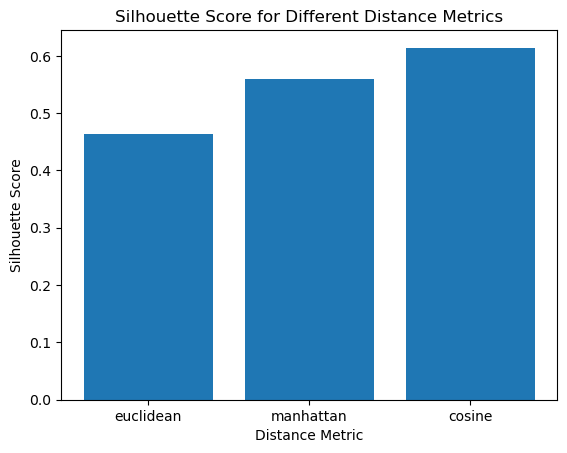

In [82]:
# Store the results in a dictionary
distance_results = {
    'euclidean': euclidean_silhouette,
    'manhattan': manhattan_silhouette,
    'cosine': cosine_silhouette
}

# Plot distance metric results
metrics = list(distance_results.keys())
scores = list(distance_results.values())

plt.bar(metrics, scores)
plt.xlabel('Distance Metric')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Distance Metrics')
plt.show()

In [83]:
# ---- Cosine MiniBatch KMeans ----
from sklearn.preprocessing import normalize

sample_size = min(50000, len(scaled_features_df))  # Sample of 50 000
sample_data = scaled_features_df.sample(n=sample_size, random_state=50)
X_normalized = normalize(sample_data)
n_clusters = int(best_n_clusters)

# Function to run MiniBatchKMeans with cosine distance approximation
def cosine_minibatch_kmeans(X, k, batch_size=5000):
    # MiniBatchKMeans with normalized data
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, n_init=10, random_state=42)
    labels = minibatch_kmeans.fit_predict(X)
    return labels, minibatch_kmeans

# Run MiniBatchKMeans
labels, cosine_minibatch_model = cosine_minibatch_kmeans(X_normalized, int(best_n_clusters))

In [84]:
silhouette_avg = silhouette_score(X_normalized, labels)
print(f'Silhouette Score: {silhouette_avg}')

Silhouette Score: 0.40625166982676225


In [85]:
sample_data['Cluster_MiniCosine'] = labels
cluster_distribution = sample_data['Cluster_MiniCosine'].value_counts().sort_index()
sorted_cluster_distribution = dict(sorted(cluster_distribution.items(), key=lambda item: item[1], reverse=True))
print("Cluster Distribution :")
for cluster, count in sorted_cluster_distribution.items():
    print(f"Cluster {cluster}: {count} ")

Cluster Distribution :
Cluster 3: 8941 
Cluster 5: 6776 
Cluster 0: 6242 
Cluster 6: 5369 
Cluster 8: 5125 
Cluster 1: 4707 
Cluster 2: 4352 
Cluster 7: 3228 
Cluster 4: 2908 
Cluster 9: 2352 


In [86]:
def cluster_profile(df, cluster_col):
    cluster_profiles = df.groupby(cluster_col).mean()  # Use .median() if preferred
    return cluster_profiles

# Get cluster profiles
cluster_profiles_minicosine = cluster_profile(sample_data, 'Cluster_MiniCosine')

customer_clusters_minicosine = retail[['CustomerID']].drop_duplicates().merge(
    sample_data[['Cluster_MiniCosine']], 
    how='left', 
    left_index=True, 
    right_index=True
)

# Formatting UnitPrice and TotalPrice to two decimal places
cluster_profiles_minicosine['UnitPrice'] = cluster_profiles_minicosine['UnitPrice'].round(2)
cluster_profiles_minicosine['TotalPrice'] = cluster_profiles_minicosine['TotalPrice'].round(2)

print("\nCluster Profiles:")
print(cluster_profiles_minicosine)
print(customer_clusters.head(20)) 


Cluster Profiles:
                    Quantity  InvoiceMonth  UnitPrice  TotalPrice  \
Cluster_MiniCosine                                                  
0                   1.280312     -0.083137      -0.49        0.79   
1                   0.046381     -0.083516      -0.22        0.03   
2                   0.089304      0.007025      -0.26       -0.08   
3                  -0.582958     -0.164298      -0.44       -0.52   
4                   0.235227      0.108995      -0.59       -0.28   
5                  -0.588424      0.158812       1.44        0.03   
6                  -0.036444     -0.129567       0.06       -0.02   
7                  -0.140719      0.183377       0.37        0.19   
8                  -0.073781     -0.176395       0.14       -0.00   
9                   0.273199      0.744806      -0.31        0.02   

                    Category_Christmas Items  Category_Decorative Items  \
Cluster_MiniCosine                                                        
0 

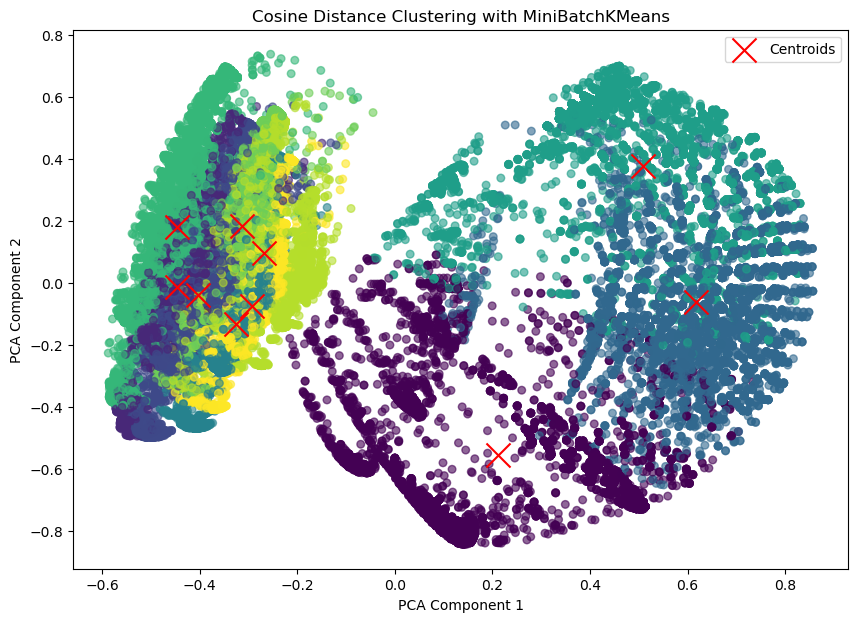

In [87]:
# PCA to reduce dimensions for visualization (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

# Apply PCA on the centroids 
centroids = cosine_minibatch_model.cluster_centers_
centroids_pca = pca.transform(centroids)

# Plot the clusters and centroids in 2D
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=30, alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='x', label='Centroids')  # Centroids
plt.title("Cosine Distance Clustering with MiniBatchKMeans")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [88]:
import joblib
import pandas as pd

# Save normal Kmeans model --> final_kmeans, cluster_profiles
# Save Cosine Kmeans model --> customer_clusters_cosinekmeans, cluster_profiles_cosinekmeans 
# Save MiniBatchKMeans model --> final_minikmean, cluster_profiles_minikmean
# Save Cosine MiniBatchKmeans model --> cosine_minibatch_model, cluster_profiles_minicosine

joblib.dump(final_kmeans, 'kmeans_model.pkl')

# Save cluster labels and centroids
retail['Cluster'] = final_kmeans.labels_
retail.to_csv('clustered_data.csv', index=False)

# Save cluster profiles
cluster_profiles.to_csv('cluster_profiles.csv', index=True)

print("Model, cluster labels, centroids, and profiles saved successfully.")

Model, cluster labels, centroids, and profiles saved successfully.
